# 02 — Retrieval Evaluation

This notebook evaluates retrieval quality using RAGAS and tests advanced retriever strategies to select the best one for the CertOps certification pipeline.



- Synthetic test set + baseline RAGAS evaluation (faithfulness, context precision, context recall) 
- Advanced retrieval techniques with RAGAS comparison table 
- Retriever selection decision 

In [1]:
import os, copy, time, uuid
from pathlib import Path
from typing import Literal
from typing_extensions import List, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown
import pandas as pd

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_qdrant import QdrantVectorStore
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langgraph.graph import START, StateGraph
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank
from qdrant_client.models import Filter, FieldCondition, MatchValue
from langsmith import Client

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset.graph import KnowledgeGraph, Node, NodeType
from ragas.testset.transforms import default_transforms, apply_transforms
from ragas.testset import TestsetGenerator
from ragas.testset.synthesizers import (
    SingleHopSpecificQuerySynthesizer,
    MultiHopAbstractQuerySynthesizer,
    MultiHopSpecificQuerySynthesizer,
)
from ragas import evaluate, EvaluationDataset, RunConfig
from ragas.metrics import Faithfulness, ContextPrecision, ContextRecall

load_dotenv(Path("../.env"))

QDRANT_URL = os.getenv("QDRANT_URL")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
COHERE_API_KEY = os.getenv("COHERE_API_KEY")
COLLECTION_NAME = "certops_docs"

## 1. Synthetic Data Generation (SDG)

We use RAGAS to build a knowledge graph from the ingested docs and generate a synthetic test set with a 50 / 25 / 25 query distribution:

| Synthesizer | Share | Rationale |
|-------------|-------|-----------|
| **SingleHopSpecific** | 50 % | Foundational / user-track questions that target a single chunk |
| **MultiHopAbstract** | 25 % | System-thinking questions for AI Champions, connecting concepts across domains |
| **MultiHopSpecific** | 25 % | Cross-domain factual questions requiring precise multi-chunk retrieval |

### 1a. Load Documents for the knowledge graph.

In [2]:
loader = DirectoryLoader("../data/docs", glob="*.md", loader_cls=TextLoader)
docs = loader.load()
print(f"Loaded {len(docs)} documents: {[d.metadata['source'] for d in docs]}")


Loaded 77 documents: ['../data/docs/5-highlight-key.md', '../data/docs/generate-formulas-with-copilot-in-excel.md', '../data/docs/5-brainstorm-new-ideas-lists-reports.md', '../data/docs/4-draft-emails-replies-meeting-agendas-microsoft-copilot-outlook.md', '../data/docs/6-performance-analysis.md', '../data/docs/custom-entities.md', '../data/docs/bring-autonomous-agents-into-enterprise.md', '../data/docs/5-ask.md', '../data/docs/advanced-ai-features.md', '../data/docs/5-rewrite-messages-replies-tone-copilot-outlook.md', '../data/docs/nlu-boost-conversations.md', '../data/docs/2-power-automate.md', '../data/docs/overview.md', '../data/docs/4-analyze-work-tables-using-copilot-excel.md', '../data/docs/environments-first-run-experience.md', '../data/docs/5-brainstorm-new-ideas-lists-reports-across-microsoft-365-microsoft-copilot.md', '../data/docs/3-add-images-slides-organize-presentation-copilot-powerpoint.md', '../data/docs/test-refine-autonomous-agent.md', '../data/docs/get-started-with-c

### 1b. Build Knowledge Graph & Generate Test Set

In [7]:
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())


### 1c. Build Nodes & Relationships

In [8]:
kg = KnowledgeGraph()
print(f'Default Knowledge Graph: {kg}')

# Create Nodes for the knowledge graph
for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )

# Apply transforms to the knowledge graph to get relationships
transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
print(f'Knowledge Graph with Nodes: {kg.nodes} and relationships: {kg.relationships}')

Default Knowledge Graph: KnowledgeGraph(nodes: 0, relationships: 0)


Applying HeadlinesExtractor:   0%|          | 0/74 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/77 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node


Applying SummaryExtractor:   0%|          | 0/88 [00:00<?, ?it/s]

...

Applying CustomNodeFilter:   0%|          | 0/142 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/332 [00:00<?, ?it/s]

Property 'summary_embedding' already exists in node '531403'. Skipping!
Property 'summary_embedding' already exists in node 'ab885c'. Skipping!
Property 'summary_embedding' already exists in node '4b61f9'. Skipping!
Property 'summary_embedding' already exists in node '61f4f1'. Skipping!
Property 'summary_embedding' already exists in node '7552f5'. Skipping!
Property 'summary_embedding' already exists in node 'f54d37'. Skipping!
Property 'summary_embedding' already exists in node '67c210'. Skipping!
Property 'summary_embedding' already exists in node '31f5db'. Skipping!
Property 'summary_embedding' already exists in node '5e80c4'. Skipping!
Property 'summary_embedding' already exists in node '171c81'. Skipping!
Property 'summary_embedding' already exists in node '1892a1'. Skipping!
Property 'summary_embedding' already exists in node '8ee209'. Skipping!
Property 'summary_embedding' already exists in node 'ba6b36'. Skipping!
Property 'summary_embedding' already exists in node '71fd63'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Knowledge Graph with Nodes: [Node(id: 1b1616, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: 65dc34, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: fca5b8, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: a972d8, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: 58b764, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: 77eb66, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding']), Node(id: 531403, type: NodeType.DOCUMENT, properties: ['page_content', 'document_metadata', 'headlines', 'summary', 'summary_embedding'])

In [29]:
print(f'Knowledge Graph: {kg}')

Knowledge Graph: KnowledgeGraph(nodes: 213, relationships: 4580)


### 1d. Persist Knowledge Graph

In [9]:
kg.save("certops_kg.json")
certops_kg = KnowledgeGraph.load("certops_kg.json")
certops_kg

KnowledgeGraph(nodes: 213, relationships: 4580)

### 1e. Query Distribution

From my experience leading as a **Senior AI Enablement Manager** conducting Copilot trainings, the query patterns differ significantly between our two audience tracks:

**M365 Copilot Users** (Foundational) tend to ask direct, single-chunk questions: 
- *How do I use Copilot in Teams?* 
- *Where do I activate Copilot?*
- *Does Copilot store my history?* 
- *Who can see my prompts?* 

This is the majority of what I encounter in training sessions, which is why `SingleHopSpecific` gets 50% of the distribution.

---


**AI Champions** (Intermediate) need to be system thinkers. They're not just using Copilot; they're building agents that connect internal data sources, APIs, custom connectors, and Power Platform resources. That requires understanding how the pieces fit together: 
- *What security controls apply when I connect an agent to internal data?*
- *How does DLP interact with the custom connectors my agent uses?* 

These cross-domain questions are covered by `MultiHopSpecific` (25%) for combining concrete facts across domains and `MultiHopAbstract` (25%) for higher-level synthesis because a system thinker needs to reason about how governance, security, and architecture work together, not just recall isolated facts.

---

This **50/25/25** split reflects the real distribution of complexity across both audiences; foundational users need accurate single-fact retrieval. In contrast, AI Champions need the system to surface and connect knowledge across domains, the way a systems thinker would.

In [10]:
generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=certops_kg)

# Define the query distribution
query_distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.50),
    (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
    (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

# Generate a test set of 10 questions
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,did adele vance propose any changes in the tea...,[[Read in English](#) Add Add to plan # Highli...,The context provides an example of how to craf...,single_hop_specifc_query_synthesizer
1,"Is Copilot in Teams available for Mac users, a...",[Explore more When you first open **Copilot in...,"Copilot in Teams is available on Mac, as well ...",single_hop_specifc_query_synthesizer
2,Wht is Copilot in Excel used for?,[[Copilot](/en-us/copilot-skilling) [Copilot i...,Copilot in Excel helps you generate formula ro...,single_hop_specifc_query_synthesizer
3,How does Microsoft 365 Copilot Chat integrate ...,[[Read in English](#) Add Add to plan # Brains...,Microsoft 365 Copilot Chat integrates with One...,single_hop_specifc_query_synthesizer
4,how copilot in outlook help me write email fas...,[[Read in English](#) Add Add to plan # Draft ...,Copilot in Outlook helps you write emails quic...,single_hop_specifc_query_synthesizer
5,How can prompt crafting techniques enhance the...,[<1-hop>\n\n[Read in English](#) Add Add to pl...,Prompt crafting techniques significantly enhan...,multi_hop_abstract_query_synthesizer
6,What AI-powered features does Microsoft Teams ...,[<1-hop>\n\nFAQ](#bkmk_faq) ## View recap To v...,Microsoft Teams offers AI-powered features in ...,multi_hop_abstract_query_synthesizer
7,How can an AI systems architect effectively te...,[<1-hop>\n\n[Read in English](#) Add Add to pl...,An AI systems architect can test generative AI...,multi_hop_abstract_query_synthesizer
8,how copilot in teams help recap meeting when i...,[<1-hop>\n\n[Read in English](#) Add Add to pl...,Copilot in Microsoft Teams enhances collaborat...,multi_hop_specific_query_synthesizer
9,how copilot prompt gallery help with copilot p...,[<1-hop>\n\n[Copilot](/en-us/copilot-skilling)...,The Copilot Prompt Gallery provides prompt sug...,multi_hop_specific_query_synthesizer


In [11]:
testset.to_pandas().to_csv("../data/synthetic_testset.csv", index=False)
print("Saved synthetic testset to data/synthetic_testset.csv")

Saved synthetic testset to data/synthetic_testset.csv


### 1f. Upload Test Set to LangSmith

Persisting the test set to LangSmith enables versioned evaluation runs and side-by-side comparison across retriever strategies.

In [12]:
client = Client()

langsmith_dataset_name = f"CertOps Synthetic Data {uuid.uuid4()}"
langsmith_dataset = client.create_dataset(
    dataset_name=langsmith_dataset_name,
    description="Synthetic Data for CertOps"
)

#add each example to the test set
for data_row in testset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

**LangSmith Dataset Dashboard**

![LangSmith Dataset Dashboard](../Langsmith_dataset.png)

## 2. Baseline RAGAS Evaluation

For each question we retrieve context, generate an answer, then evaluate with RAGAS:
- **Faithfulness** — is the answer grounded in the retrieved context? (no hallucination)
- **Context Precision** — are relevant contexts ranked higher?
- **Context Recall** — did we retrieve all contexts needed to answer?

### 2a. Baseline RAG Graph


In [ ]:
#baseline retriever
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o", temperature=0)

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

baseline_retriever = vector_store.as_retriever(search_kwargs={"k": 5})

#rag chain
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer the question using only the provided context. Be concise and accurate."),
    ("human", "Context:\n{context}\n\nQuestion: {question}\n\nAnswer:"),
])
rag_chain = rag_prompt | llm | StrOutputParser()

print("Retriever and RAG chain ready.")

Retriever and RAG chain ready.


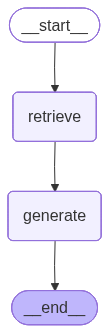

In [15]:
class State(TypedDict):
    question: str
    context: List[Document]
    response: str
    
def retrieve(state):
    docs = baseline_retriever.invoke(state["question"])
    return {"context": docs}

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
baseline_graph = graph_builder.compile()

display(Image(baseline_graph.get_graph().draw_mermaid_png()))

In [16]:
response = baseline_graph.invoke({"question": "What is Copilot Studio?"})
Markdown(response["response"])

Copilot Studio is a platform that provides tools to create, test, publish, and monitor the performance of autonomous agents. It allows users to enhance declarative agents with additional capabilities and offers features for measuring and improving agent performance through analytics and engagement metrics.

### 2b. Evaluate Baseline Retriever/Graph with RAGAS

In [17]:
for test_row in testset:
  response = baseline_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

evaluation_dataset = EvaluationDataset.from_pandas(testset.to_pandas())

Markdown(testset.samples[0].eval_sample.response)


Adele Vance did propose changes during the Teams meeting. Here is the project timeline in a table format:

| Phase          | Start Date | End Date   |
|----------------|------------|------------|
| Planning       | Jan 1, 2024| Jan 15, 2024|
| Development    | Jan 16, 2024| Mar 31, 2024|
| Testing        | Apr 1, 2024| Apr 30, 2024|
| Deployment     | May 1, 2024| May 15, 2024|

Adele proposed extending the Testing phase by two weeks to ensure thorough quality checks.

In [18]:
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[Faithfulness(), ContextPrecision(), ContextRecall()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
baseline_result

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

{'faithfulness': 0.6177, 'context_precision': 0.4093, 'context_recall': 0.5931}

`faithfulness` (0.62) indicates moderate grounding.`context_precision` (0.41) is the weakest metric. The retriever returns relevant chunks but struggles to rank them highest. `context_recall` (0.59) shows it captures roughly half the required evidence. These scores motivate testing advanced retriever strategies below.

## 3. Advanced Retriever Strategies

We test three alternatives to improve on the baseline:

| Strategy | Approach | Why it might help |
|----------|----------|-------------------|
| **Reranked** | Retrieve top-20, re-score with LLM, keep top-5 | Better precision, cross-encoder sees query+doc together |
| **Filtered (Single Domain)** | Classify single query domain, filter Qdrant, then retrieve | Less noise, eliminates irrelevant domain chunks |
| **Filtered(Multi-Domain)** | Classify query domain(1-3), filter Qdrant, then retrieve | Takes account of `MultiHopSpecific` and `MultiHopAbstract` within the query distribution |

*All advanced graphs reuse the same `State` and `generate` node from Section 2. Only the retrieval node changes.*

### 3a. Reranked Retriever (Cohere)

Qdrant → top 20 → Cohere `rerank-v3.5` picks best 5 → LLM

In [ ]:
def rerank_retriever(state):
  wide_net_retriever = vector_store.as_retriever(search_kwargs={"k": 20})
    
  # Cohere reranker picks the best 5 from the 20
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=wide_net_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

reranked_graph_builder = StateGraph(State).add_sequence([rerank_retriever, generate])
reranked_graph_builder.add_edge(START, "rerank_retriever")
reranked_graph = reranked_graph_builder.compile()


reranked_dataset = copy.deepcopy(testset)

for test_row in reranked_dataset:
  response = reranked_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(10)


reranked_evaluation_dataset = EvaluationDataset.from_pandas(reranked_dataset.to_pandas())

reranked_result = evaluate(
    dataset=reranked_evaluation_dataset,
    metrics=[Faithfulness(), ContextPrecision(), ContextRecall()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
reranked_result

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

{'faithfulness': 0.7923, 'context_precision': 0.5000, 'context_recall': 0.5801}

### Reranked vs. Baseline

| Metric | Baseline | Reranked | Change |
|---|---|---|---|
| Faithfulness | 0.62 | 0.79 | **+0.17** |
| Context Precision | 0.41 | 0.50 | **+0.09** |
| Context Recall | 0.59 | 0.58 | −0.01 |

The Cohere reranker improved `faithfulness` (+0.17) and `context_precision` (+0.09) while keeping `context_recall` essentially flat. The cross-encoder sees query and document together, which helps promote truly relevant chunks.

Next, we test a **domain-filtered retriever** that uses an LLM classifier to pre-filter Qdrant by domain before retrieval.

### 3b. Filtered Retriever — Single Domain

An LLM classifier (`gpt-4o-mini`) predicts a single domain for each query, then Qdrant filters to that domain before retrieval.

In [27]:
classify_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

DOMAINS = ["architecture", "connectors", "security", "governance",
           "overview", "productivity", "communication", "data-analysis", "prompting", "adoption"]

class DomainClassification(BaseModel):
    domain: Literal[
        "architecture", "connectors", "security", "governance",
        "overview", "productivity", "communication", "data-analysis",
        "prompting", "adoption"
    ] = Field(description="The single most relevant domain for the user's question")

def classify_one_domain(query: str) -> str:
    response = classify_llm.with_structured_output(DomainClassification).invoke(
        f"Classify this question into the most relevant domain.\nQuestion: {query}"
    )
    return response.domain

def retrieve_one_domain_filtered(state):
    domain = classify_one_domain(state["question"])
    f = Filter(must=[FieldCondition(key="metadata.domain", match=MatchValue(value=domain))])
    filtered_retriever = vector_store.as_retriever(search_kwargs={"k": 5, "filter": f})
    docs = filtered_retriever.invoke(state["question"])
    return {"context": docs}

filter_by_domain_graph_builder = StateGraph(State).add_sequence([retrieve_one_domain_filtered, generate])
filter_by_domain_graph_builder.add_edge(START, "retrieve_one_domain_filtered")
filter_by_domain_graph = filter_by_domain_graph_builder.compile()



filtered_one_domain_dataset = copy.deepcopy(testset)

for test_row in filtered_one_domain_dataset:
  response = filter_by_domain_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]


filtered_one_domain_evaluation_dataset = EvaluationDataset.from_pandas(filtered_one_domain_dataset.to_pandas())

filtered_one_domain_result = evaluate(
    dataset=filtered_one_domain_evaluation_dataset,
    metrics=[Faithfulness(), ContextPrecision(), ContextRecall()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
filtered_one_domain_result

/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DomainClassification(domain='productivity'), input_type=DomainClassification])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DomainClassification(domain='prompting'), input_type=DomainClassification])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

{'faithfulness': 0.6686, 'context_precision': 0.2636, 'context_recall': 0.2587}

### 3c. Filtered Retriever — Multi Domain

Allow the classifier to return 1–3 domains and use a Qdrant `should` (OR) filter.

In [30]:
class MultiDomainClassification(BaseModel):
    domains: list[Literal[
        "architecture", "connectors", "security", "governance",
        "overview", "productivity", "communication", "data-analysis",
        "prompting", "adoption"
    ]] = Field(description="The relevant domains for the user's question (1-3)")

def classify_multi_domain(query: str) -> str:
    response = classify_llm.with_structured_output(MultiDomainClassification).invoke(
        f"Classify this question into 1-3 relevant domains.\nQuestion: {query}"
    )
    return response.domains

def retrieve_multi_domain_filtered(state):
    result = classify_llm.with_structured_output(MultiDomainClassification).invoke(
        f"Classify this question into 1-3 relevant domains.\nQuestion: {state['question']}"
    )
    conditions = [
        FieldCondition(key="metadata.domain", match=MatchValue(value=d))
        for d in result.domains
    ]
    f = Filter(should=conditions)
    filtered_retriever = vector_store.as_retriever(search_kwargs={"k": 5, "filter": f})
    docs = filtered_retriever.invoke(state["question"])
    return {"context": docs}

multi_domain_graph_builder = StateGraph(State).add_sequence([retrieve_multi_domain_filtered, generate])
multi_domain_graph_builder.add_edge(START, "retrieve_multi_domain_filtered")
multi_domain_graph = multi_domain_graph_builder.compile()

filtered_dataset = copy.deepcopy(testset)

for test_row in filtered_dataset:
  response = multi_domain_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

filtered_evaluation_dataset = EvaluationDataset.from_pandas(filtered_dataset.to_pandas())

filtered_result = evaluate(
    dataset=filtered_evaluation_dataset,
    metrics=[Faithfulness(), ContextPrecision(), ContextRecall()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
filtered_result

/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MultiDomainClassification...ication', 'governance']), input_type=MultiDomainClassification])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=MultiDomainClassification...unication', 'adoption']), input_type=MultiDomainClassification])
  return self.__pydantic_serializer__.to_python(
/Users/josephmata/Documents/Cloud_backup/CertOps/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  Pydan

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

{'faithfulness': 0.7335, 'context_precision': 0.4827, 'context_recall': 0.6299}

## 5. Retriever Comparison Table

| Metric | Baseline | Reranked (Cohere) | Filtered (Single Domain) | Filtered (Multi Domain) |
|---|---|---|---|---|
| Faithfulness | 0.62 | **0.79** | 0.67 | 0.73 |
| Context Precision | 0.41 | **0.50** | 0.26 | 0.48 |
| Context Recall | **0.59** | 0.58 | 0.26 | 0.63 |

### Analysis

**Winner: Reranked retriever (Cohere `rerank-v3.5`, k=20 → top 5)**

The Cohere reranker outperformed every other strategy on the two metrics that matter most for a certification system — faithfulness and context precision — while keeping context recall essentially flat.

**Reranked (Cohere):** Faithfulness jumped from 0.62 to 0.79 (+0.17), and context precision rose from 0.41 to 0.50 (+0.09). The cross-encoder sees query and document together, which helps promote genuinely relevant chunks and ground the LLM answer more faithfully. Context recall dipped marginally (0.59 → 0.58), a negligible trade-off.

**Filtered (Single Domain):** Pre-filtering by a single-domain classifier  all metrics sharply. The core issue: our synthetic test set includes multi-hop questions (25% `MultiHopSpecific` + 25% `MultiHopAbstract`) that span multiple domains. A single-domain lock excludes the cross-domain chunks those questions require.

**Filtered (Multi Domain):** Pre-filtering by a multi-domain classifier had the highest `context_recall`. It correctly identified those domains and pulled from all of them, so more of the ground-truth-relevant chunks get retrieved.



### Retriever Decision

**We select the Cohere reranked retriever.**

It delivers the highest faithfulness (0.79) and context precision (0.50), the two most critical metrics for a certification system where accuracy and grounding must be reliable. Context recall (0.58) remains competitive with baseline (0.59).

